In [1]:
import numpy as np
import cv2
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", device)


device: cuda


In [2]:
# 문제 1: 모든 이미지는 중앙에 위치해야 함. 크기가 이미지로 꽉 차야 함.
# 해결 1: 학습 데이터 증강 -> 원본 이미지로 새로운 이미지 생성.
# (전체 꽉 찬 이미지를 여러 방향으로 회전, 작게 만들어 여러 공간에 위치)
# 학습용: 이동/크기/회전/기울임 증강  ← 위치·크기 변화에 강건해짐
train_tf = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.12, 0.12),
                            scale=(0.75, 1.25), shear=8, fill=0),   # 이동/크기/회전/기울임 증강한 코드.
    transforms.ToTensor(),          # [0,1] 스케일링
])  # 학습용만 증강, 테스트용은 증강하지 않기.
# 평가용: 증강 없음
eval_tf = transforms.ToTensor()


train_set = datasets.MNIST("data", train=True,  download=True, transform=train_tf)  
                                                                # train 데이터 다운받으면서 증강
test_set  = datasets.MNIST("data", train=False, download=True, transform=eval_tf)


train_loader = DataLoader(train_set, batch_size=64, shuffle=True)   # shuffle=false면 위치를 외움.


# 검증/테스트: (N,1,28,28) float32, [0,1] — 학습과 동일한 스케일
x_all = test_set.data.float().div(255.0).unsqueeze(1)   
y_all = test_set.targets
x_val,  y_val  = x_all[:5000], y_all[:5000]
x_test, y_test = x_all[5000:], y_all[5000:]
print(x_val.shape, x_val.min().item(), x_val.max().item())

torch.Size([5000, 1, 28, 28]) 0.0 1.0


In [3]:
# 해결 2: 원본 이미지 중앙, 크기 꽉 차게 전처리

In [ ]:
# 모델 구조 설계
class CNN_model(nn.Module): # 1. 신경망 상속
    """28 →(pool) 14 →(pool) 7 →(pool) 3  →  128*3*3 = 1152"""
    def __init__(self, n_classes=10):   # 2. 신경망 층 생성
        super().__init__()  # 상위 오브젝트 생성(nn.Module). 부모 클래스 생성.
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        self.conv1 = block(1, 32)      # 28 → 14
        self.conv2 = block(32, 64)     # 14 → 7
        self.conv3 = block(64, 128)    # 7  → 3     # 3.5아님.
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )


    def forward(self, x):   # 3. 순전파/역전파 학습
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.head(x)


model = CNN_model().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
print("params:", sum(p.numel() for p in model.parameters()))   # 약 40만 개
 

params: 390858


In [5]:
# 학습 함수
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total = 0.0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)


        optimizer.zero_grad()            # ① 기울기 초기화
        pred = model(x)                  # ② 순전파
        loss = loss_fn(pred, y)
        loss.backward()                  # ③ 역전파
        optimizer.step()                 # ④ 파라미터 갱신


        total += loss.item()             # ★ .item() — 텐서 누적 금지(메모리 누수)
    return total / len(dataloader)


In [7]:
@torch.no_grad()
def evaluate(x, y, model, loss_fn, device, batch_size=512):
    """배치 단위 평가 — 5000장을 한 번에 GPU에 올리지 않음"""
    model.eval()
    loss_sum, preds = 0.0, []
    for i in range(0, len(x), batch_size):
        xb, yb = x[i:i+batch_size].to(device), y[i:i+batch_size].to(device)
        out = model(xb)
        loss_sum += loss_fn(out, yb).item() * len(xb)   # 샘플 가중합
        preds.append(out.cpu())
    return loss_sum / len(x), torch.cat(preds)

In [8]:
# 시각화 함수
def dl_learning_curve(tr, va):
    e = range(1, len(tr) + 1)
    plt.plot(e, tr, marker='.', label='train')
    plt.plot(e, va, marker='.', label='val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(); plt.show()


Epoch  1 | train 0.2838 | val 0.0691
Epoch  2 | train 0.1151 | val 0.0373
Epoch  3 | train 0.0947 | val 0.0314
Epoch  4 | train 0.0805 | val 0.0276
Epoch  5 | train 0.0719 | val 0.0354
Epoch  6 | train 0.0688 | val 0.0244
Epoch  7 | train 0.0609 | val 0.0194
Epoch  8 | train 0.0583 | val 0.0330
Epoch  9 | train 0.0532 | val 0.0221
Epoch 10 | train 0.0521 | val 0.0264
Epoch 11 | train 0.0526 | val 0.0213
Epoch 12 | train 0.0506 | val 0.0209
Epoch 13 | train 0.0493 | val 0.0209
Epoch 14 | train 0.0462 | val 0.0183
Epoch 15 | train 0.0456 | val 0.0185


C:\Users\mega\AppData\Local\Temp\ipykernel_10472\995333188.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mnist_cnn.pt", map_loc

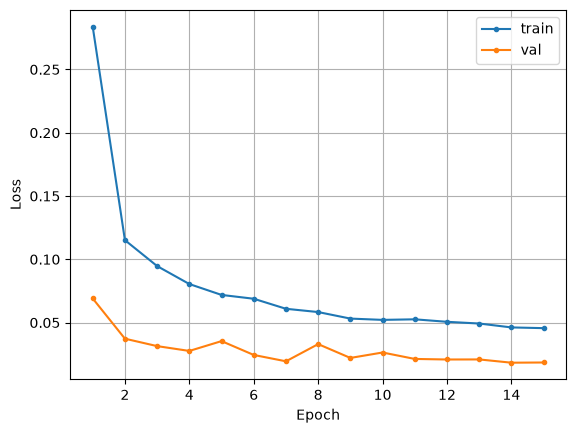

              precision    recall  f1-score   support

           0     1.0000    0.9962    0.9981       520
           1     0.9965    1.0000    0.9982       564
           2     0.9921    0.9980    0.9950       502
           3     0.9980    0.9961    0.9971       510
           4     1.0000    0.9979    0.9990       482
           5     0.9954    0.9954    0.9954       436
           6     0.9960    0.9960    0.9960       496
           7     0.9884    0.9942    0.9913       516
           8     0.9979    0.9938    0.9959       485
           9     0.9979    0.9939    0.9959       489

    accuracy                         0.9962      5000
   macro avg     0.9962    0.9961    0.9962      5000
weighted avg     0.9962    0.9962    0.9962      5000



In [ ]:
# 학습
epochs = 15                      # 증강을 쓰면 에포크를 조금 더 주는 편이 좋음
tr_list, va_list = [], []
best = float('inf') # best => 오차가 작은 게 베스트. 베스트 초기값을 제일 큰 값으로 준 것. 그 다음 수가 초기값보다 무조건 작은 값이어야 해서.


for t in range(epochs):
    tr = train(train_loader, model, loss_fn, optimizer, device)
    va, _ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_list.append(tr); va_list.append(va)
    print(f"Epoch {t+1:2d} | train {tr:.4f} | val {va:.4f}")


    if va < best:                # 검증 오차 최저 시점 저장
        best = va
        torch.save(model.state_dict(), "best_mnist_cnn.pt")     # model.state_dict() : 상태 딕셔너리. 오차 작은 모델 상태 저장하라는 뜻.


model.load_state_dict(torch.load("best_mnist_cnn.pt", map_location=device))     # 베스트 모델 불러오기.
dl_learning_curve(tr_list, va_list)


_, logits = evaluate(x_test, y_test, model, loss_fn, device)
pred = logits.argmax(dim=1).numpy()
print(classification_report(y_test.numpy(), pred, digits=4))

# train이 val보다 loss 높은 이유는 증강 때문.(기존에 없는 이미지(증강이미지)로 학습하며 train loss가 큼.)

In [10]:
# 예측값 추출하는 함수
@torch.no_grad()
def predict_digit(model, img28, device, tta=True, topk=3):
    """img28: preprocess_like_mnist 결과 (28,28) uint8"""
    model.eval()
    x = torch.tensor(img28, dtype=torch.float32).div(255.0).view(1, 1, 28, 28)


    batch = [x]
    if tta:                                   # 상하좌우 1px 이동본을 함께 평가
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            batch.append(torch.roll(x, shifts=(dy, dx), dims=(2, 3)))
    batch = torch.cat(batch).to(device)


    probs = torch.softmax(model(batch), dim=1).mean(dim=0).cpu().numpy()
    order = probs.argsort()[::-1][:topk]
    return int(order[0]), [(int(i), float(probs[i])) for i in order]


In [11]:
# 중앙 이동 함수
def _center_of_mass(a):
    """scipy 없이 픽셀 질량중심 (y, x) 계산"""
    total = a.sum(dtype=np.float64)
    if total == 0:
        return a.shape[0] / 2.0, a.shape[1] / 2.0
    ys, xs = np.indices(a.shape)
    return ((ys * a).sum(dtype=np.float64) / total,
            (xs * a).sum(dtype=np.float64) / total)

In [21]:
# 원본 이미지 => MNIST 함수
def preprocess_like_mnist(img, box=20, canvas=28, thicken=True, return_steps=False):
    """
    임의의 손글씨 이미지를 MNIST 규격(28x28, 검은 배경/흰 글씨, 20px 박스,
    질량중심 중앙 정렬)으로 변환한다.
    반환: uint8 (28,28)
    """
    if img is None:
        raise ValueError("이미지를 읽지 못했습니다.")
    if img.ndim == 3:                                  # 컬러면 그레이스케일
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.uint8)
    steps = {"0_원본": img.copy()}


    # ── 1) 배경 밝기 자동 판별 → 항상 "검은 배경 + 흰 글씨"로 통일
    #     테두리 4변의 평균 밝기로 배경색을 추정 (255-img 하드코딩 제거)
    border = np.concatenate([img[0, :], img[-1, :], img[:, 0], img[:, -1]])
    if border.mean() > 127:
        img = 255 - img
    steps["1_반전"] = img.copy()


    # ── 2) Otsu 이진화: 안티앨리어싱/압축 잡음/회색 잔상 제거
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    steps["2_이진화"] = binary.copy()


    # ── 3) 획 두께 보정 (★ 축소 전에 수행해야 얇은 획이 살아남음)
    #     커널을 이미지 크기에 비례시켜 해상도와 무관하게 동작
    if thicken:
        k = int(round(min(binary.shape) / 90))
        if k >= 2:
            binary = cv2.dilate(binary, np.ones((k, k), np.uint8), iterations=1)
    steps["3_두께보정"] = binary.copy()


    # ── 4) 숫자 bounding box만 크롭 (여백 제거)
    coords = cv2.findNonZero(binary)
    if coords is None:
        raise ValueError("숫자를 찾지 못했습니다. 더 진하고 크게 그려주세요.")
    x, y, w, h = cv2.boundingRect(coords)
    digit = binary[y:y + h, x:x + w]
    steps["4_크롭"] = digit.copy()


    # ── 5) 종횡비 유지하며 긴 변을 20px로 (축소는 INTER_AREA가 정답)
    if w >= h:
        new_w, new_h = box, max(1, int(round(h * box / w)))
    else:
        new_h, new_w = box, max(1, int(round(w * box / h)))
    digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)


    # ── 6) 28x28 캔버스 중앙에 배치
    out = np.zeros((canvas, canvas), dtype=np.uint8)
    y0, x0 = (canvas - new_h) // 2, (canvas - new_w) // 2
    out[y0:y0 + new_h, x0:x0 + new_w] = digit
    steps["5_28x28배치"] = out.copy()


    # ── 7) ★ 질량중심을 캔버스 정중앙(13.5, 13.5)으로 평행이동 — MNIST 공식 규격
    cy, cx = _center_of_mass(out)
    c = (canvas - 1) / 2.0
    M = np.float32([[1, 0, round(c - cx)],
                    [0, 1, round(c - cy)]])
    out = cv2.warpAffine(out, M, (canvas, canvas),
                         flags=cv2.INTER_NEAREST, borderValue=0)
    steps["6_중심정렬"] = out.copy()


    return (out, steps) if return_steps else out


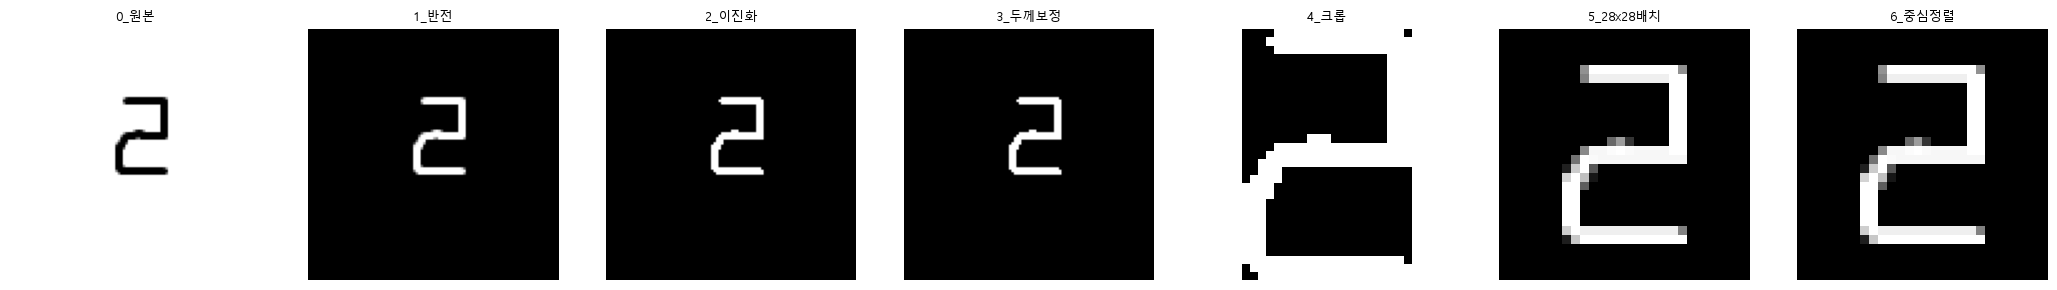

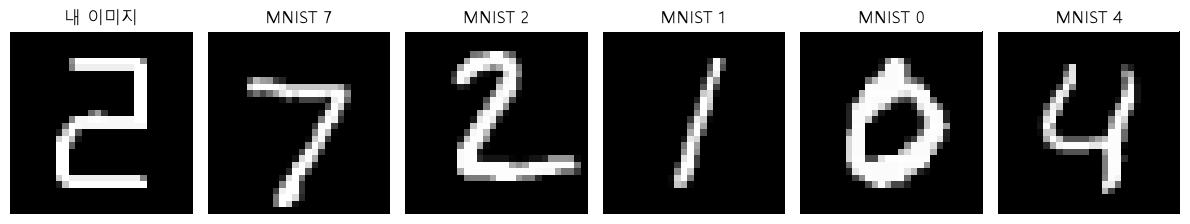

예측: 2
  2 : 98.83%
  7 : 1.02%
  8 : 0.08%


In [31]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  #


img_path = "02.png"
raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img28, steps = preprocess_like_mnist(raw, return_steps=True)


# 전처리 단계별 확인 — 문제가 생기면 어느 단계에서 깨졌는지 바로 보임
fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
for ax, (name, im) in zip(axes, steps.items()):
    ax.imshow(im, cmap='gray'); ax.set_title(name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()


# ★ 가장 중요한 검증: 내 이미지 vs 실제 MNIST 샘플을 나란히 비교
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
axes[0].imshow(img28, cmap='gray'); axes[0].set_title("내 이미지"); axes[0].axis('off')
for i in range(5):
    axes[i+1].imshow(test_set.data[i].numpy(), cmap='gray')
    axes[i+1].set_title(f"MNIST {test_set.targets[i].item()}"); axes[i+1].axis('off')
plt.tight_layout(); plt.show()


label, top = predict_digit(model, img28, device)
print(f"예측: {label}")
for d, p in top:
    print(f"  {d} : {p*100:.2f}%")
